# Heurísticas e Regras de Negócio
Aqui validamos as regras de negócio para classificação de risco (Baixo, Médio, Alto).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

contratos = pd.read_csv('contratos_clean.csv')
pagamentos = pd.read_csv('pagamentos_clean.csv', parse_dates=['Data_Vencimento', 'Data_Pagamento'])


### Classificação de Risco
- Alto: atraso > 60 dias, Ajuizado, Score > 70
- Médio: atraso > 15 dias, Insucesso
- Baixo: <= 15 dias, Em Aberto

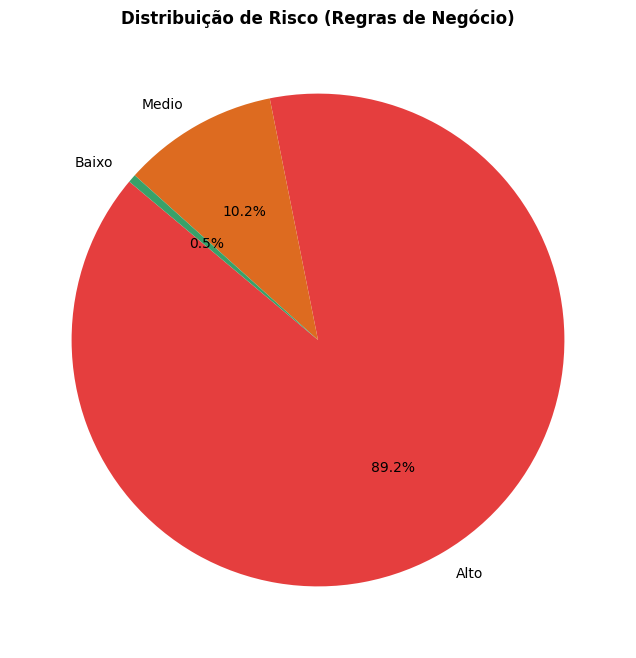

Nivel_Risco
Alto     8925
Medio    1021
Baixo      54
Name: count, dtype: int64


In [2]:
def classificar_risco(row):
    dias = row['Dias_Em_Atraso_Inicial']
    status = row['Status_Cobranca']
    score = row['Score_Interno_Risco']
    
    if dias > 60 or status == 'Ajuizado' or score > 70:
        return 'Alto'
    elif dias > 15 or status == 'Insucesso':
        return 'Medio'
    else:
        return 'Baixo'

contratos['Nivel_Risco'] = contratos.apply(classificar_risco, axis=1)
dist_risco = contratos['Nivel_Risco'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(dist_risco, labels=dist_risco.index, autopct='%1.1f%%', colors=['#e53e3e', '#dd6b20', '#38a169'], startangle=140)
plt.title('Distribuição de Risco (Regras de Negócio)', fontweight='bold')
plt.show()

print(dist_risco)